# Second run using more complex tensor

We present here a simple example to show the basic functionalities. It uses a random input tensor, more complex examples can be explored in the other [notebook](SWoTTeD_module_example.ipynb).

## Exemple d'utilisation de trajectoryclusteringanalysis (multidimensionnel)

Cette section illustre un workflow complet du package `trajectoryclusteringanalysis` :
1. Initialiser TCA en mode multidimensionnel
2. Construire le tenseur $\mathbf{X}\in\{0,1\}^{K\times N\times T}$ (patient × événement × temps)
3. Apprendre la decomposition SWoTTeD
4. Extraire les intensites de phenotypes et clusteriser les patients

In [2]:
import pandas as pd
pd.options.mode.chained_assignment = None  # default='warn'
from pathlib import Path

# Locate the repository data folder regardless of current working directory
target_name = "multidimensional_data"
data_dir = None
for base in [Path.cwd(), *Path.cwd().parents]:
    candidate = base / "data"
    if (candidate / f"{target_name}.csv").exists():
        data_dir = candidate
        break

if data_dir is None:
    raise FileNotFoundError(
        f"Could not find a 'data' folder containing {target_name}.csv. "
        f"Current working directory: {Path.cwd()}"
    )

csv_path = data_dir / f"{target_name}.csv"

if csv_path.exists():
    df = pd.read_csv(csv_path)
else:
    raise FileNotFoundError(
        f"'{csv_path}' does not exist."
    )

print(f"Loaded data from: {csv_path}")

Loaded data from: c:\Users\nicolas.grevet\dev\TrajectoryClusteringAnalysis.worktrees\copilot-worktree-2026-04-13T12-30-11\data\multidimensional_data.csv


In [3]:
df

,PATIENT_ID,EVENT,TIME
0,1,Chirurgie,0
1,1,Chimiothérapie IV,1
2,1,Chimiothérapie IV,1
3,1,Chimiothérapie IV,2
4,1,Chimiothérapie IV,3
...,...,...,...
20430,1336,Chimiothérapie IV,2
20431,1336,Chimiothérapie IV,2
20432,1336,Chimiothérapie IV,3
20433,1336,Chimiothérapie IV,3


In [4]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
timed_event_structure = df.copy()

timed_event_structure['Event'] = label_encoder.fit_transform(timed_event_structure['EVENT'])
timed_event_structure.drop(columns=['EVENT'], inplace=True)
timed_event_structure.columns = ['ID_PATIENT', 'Time', 'Event']
timed_event_structure

,ID_PATIENT,Time,Event
0,1,0,2
1,1,1,0
2,1,1,0
3,1,2,0
4,1,3,0
...,...,...,...
20430,1336,2,0
20431,1336,2,0
20432,1336,3,0
20433,1336,3,0


In [5]:
nunique = timed_event_structure['ID_PATIENT'].nunique()
print(f"Number of unique patients: {nunique}")

Number of unique patients: 1336


In [6]:
# Get the set of all unique Event values
unique_events = timed_event_structure['Event'].unique()
all_events = set(unique_events)

# Find patients who have all occurrences of Event
patients_with_all_events = timed_event_structure.groupby('ID_PATIENT').filter(
    lambda group: set(group['Event']) == all_events
)['ID_PATIENT'].unique()

print(f"Patients with all occurrences of Event: {len(patients_with_all_events)}")
print(patients_with_all_events)

Patients with all occurrences of Event: 50
[   8   23   45   65   66  134  157  173  176  178  188  194  220  228
  242  275  312  343  361  390  428  466  469  472  478  537  544  546
  575  613  665  673  688  759  775  790  792  831  845  867  895  937
  943  969  984 1081 1126 1286 1293 1333]


## Guide rapide: pipeline TCA multidimensionnel

Dans cette partie, on suit un enchainement simple et reproductible:
1. Configurer l'import du package (local)
2. Initialiser `TCA` en mode multidimensionnel
3. Construire le tenseur
4. Entrainer SWoTTeD
5. Clusteriser les intensites de phenotypes

In [7]:
from pathlib import Path
import sys
import importlib
import inspect

project_root = None
for base in [Path.cwd(), *Path.cwd().parents]:
    src_candidate = base / "src" / "trajectoryclusteringanalysis"
    if src_candidate.exists():
        project_root = base
        break

if project_root is None:
    raise FileNotFoundError(
        f"Could not find project root containing src/trajectoryclusteringanalysis from {Path.cwd()}"
    )

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import trajectoryclusteringanalysis.multidimensional.analysis as md_analysis
import trajectoryclusteringanalysis.multidimensional as md_pkg
import trajectoryclusteringanalysis.tca as tca_module
import trajectoryclusteringanalysis as tca_pkg

# Force reload to avoid stale class signature in notebook kernel
importlib.reload(md_analysis)
importlib.reload(md_pkg)
importlib.reload(tca_module)
importlib.reload(tca_pkg)

from trajectoryclusteringanalysis import TCA
from trajectoryclusteringanalysis.plotting import *

print(f"Using local package from: {src_path}")
print("Active fit_swotted_decomposition signature:")
print(inspect.signature(md_analysis.MultidimensionalAnalyzer.fit_swotted_decomposition))

Using local package from: c:\Users\nicolas.grevet\dev\TrajectoryClusteringAnalysis.worktrees\copilot-worktree-2026-04-13T12-30-11\src
Active fit_swotted_decomposition signature:
(self, tensor, rank, time_window_length, reg_term_ns=0.5, reg_term_s=0.5, metric='Bernoulli', learning_rate=0.01, n_epochs=100, fit_metric_every_n_epochs=0, fit_metric_eval_max_patients=None, restore_best_fit_checkpoint=True, num_workers=0, early_stopping_patience=10, early_stopping_min_delta=0.0001, early_stopping_monitor='train_loss_total')


### 2) Initialiser TCA (mode multidimensionnel)

`TCA` encapsule la préparation des données, la décomposition SWoTTeD et les outils de clustering/visualisation.

In [9]:
# Créer une instance de TCA pour l'analyse multidimensionnelle
tca = TCA(data=timed_event_structure,
              index_col='ID_PATIENT',
              time_col='Time', 
              event_col='Event',
              mode='multidimensional',
              )

INFO:root:TCA object initialized successfully
INFO:root:The multidimensional analysis mode is set. TCA object will analyze the data accordingly.


Dataset :
data shape:  (20435, 3)
state coding:
    label  label encoded
0      0              0
1      1              1
2      2              2
3      3              3


### 3) Construire le tenseur multidimensionnel

Transformation du format long (`ID_PATIENT`, `Time`, `Event`) vers un tenseur binaire `(K, N, T)`.

In [10]:
tca.analyzer.transform_time_event_structure_to_tensor()
print("Tensor shape:", tca.analyzer.get_tensor_shape())
tensor = tca.analyzer.get_tensor()

Tensor shape: torch.Size([1336, 4, 24])


### 4) Parametrer et entrainer SWoTTeD

Commence avec peu d'epochs pour une demo rapide, puis augmente pour ameliorer la qualite.

In [11]:
# Hyperparametres de la demo
rank = 3
time_window_length = 3
reg_term_ns = 0.9
reg_term_s = 0.1
metric = 'Bernoulli'
learning_rate = 1e-2


Patient utilise pour la visualisation: 8


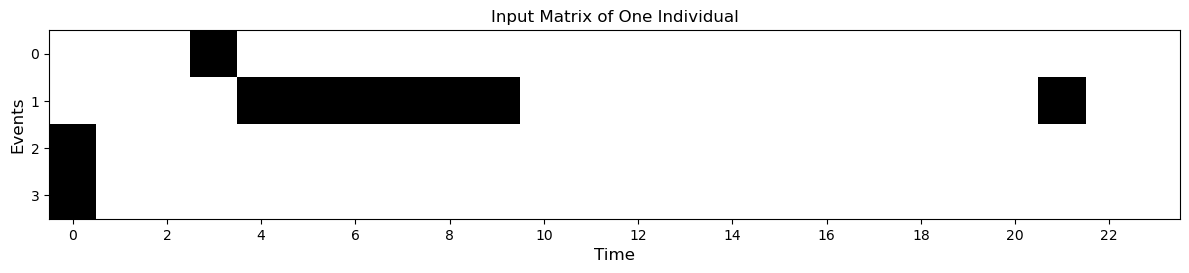

In [12]:
patient_index = int(patients_with_all_events[0])
print(f"Patient utilise pour la visualisation: {patient_index}")

plot_input_matrix(tensor, id=patient_index, labels=tca.label_to_encoded)

### Affichage des metriques

- En mode rapide (fit_metric_every_n_epochs=0), on n'affiche pas la FIT metric pendant l'entrainement pour ne pas ralentir.
- Tu peux activer la FIT metric ponctuellement avec fit_metric_every_n_epochs=10 (ou 1 pour chaque epoch).
- La success rate est affichee dans get_decomposition_results apres l'entrainement.

In [13]:
n_epochs = 200
# Sous Windows, une petite valeur comme 1 ou 2 fonctionne bien avec un collate_fn sérialisable.
tca.analyzer.fit_swotted_decomposition(tensor,
                                       rank,
                                       time_window_length,
                                       reg_term_ns, 
                                       reg_term_s, 
                                       metric, 
                                       learning_rate, 
                                       n_epochs,
                                       fit_metric_every_n_epochs=5,
                                       fit_metric_eval_max_patients=None,  # FIT approx pendant training
                                       num_workers=0,
                                       early_stopping_patience=10,
                                       early_stopping_min_delta=1e-4,
                                       early_stopping_monitor='fit_metric',)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\nicolas.grevet\AppData\Local\anaconda3\Lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
c:\Users\nicolas.grevet\AppData\Local\anaconda3\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.



 -> Starting training



  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | model        | SlidingWindow | 0      | train
  | other params | n/a           | 36     | n/a  
-------------------------------------------------------
36        Trainable params
0         Non-trainable params
36        Total params
0.000     Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval mode
c:\Users\nicolas.grevet\AppData\Local\anaconda3\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Epoch 1/200 : - train_loss_Ph: 17.582378 - train_loss_W: 46.684204 - train_loss_total: 64.266582 - duration: 1.37s - FIT metric: 0.1151
    early stopping: Metric fit_metric initialized at 0.115.
    checkpoint: New best FIT metric = 0.1151 at epoch 1.
Epoch 2/200 : - train_loss_Ph: 17.278139 - train_loss_W: 45.307884 - train_loss_total: 62.586023 - duration: 1.52s
Epoch 3/200 : - train_loss_Ph: 17.202469 - train_loss_W: 44.243568 - train_loss_total: 61.446037 - duration: 1.46s
Epoch 4/200 : - train_loss_Ph: 17.057730 - train_loss_W: 43.129898 - train_loss_total: 60.187628 - duration: 1.52s
Epoch 5/200 : - train_loss_Ph: 16.959072 - train_loss_W: 42.069191 - train_loss_total: 59.028263 - duration: 1.64s - FIT metric: 0.1046
Epoch 6/200 : - train_loss_Ph: 16.852512 - train_loss_W: 41.025291 - train_loss_total: 57.877804 - duration: 1.26s
Epoch 7/200 : - train_loss_Ph: 16.771957 - train_loss_W: 40.014572 - train_loss_total: 56.786530 - duration: 1.27s
Epoch 8/200 : - train_loss_Ph: 16.65

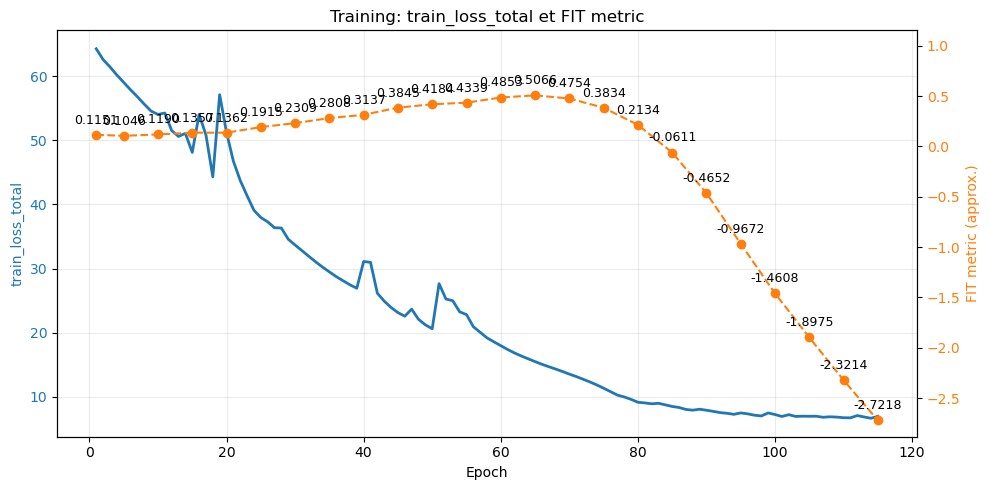

In [14]:
import matplotlib.pyplot as plt

history = getattr(tca.analyzer, 'training_history', None)
if not history or len(history.get('epoch', [])) == 0:
    raise ValueError("Aucun historique d'entrainement disponible. Execute d'abord la cellule d'entrainement.")

epochs = history['epoch']
train_loss_total = history['train_loss_total']
fit_epochs = history['fit_metric_points_epoch']
fit_values = history['fit_metric_points_value']

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(epochs, train_loss_total, color='tab:blue', linewidth=2, label='train_loss_total')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('train_loss_total', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(alpha=0.25)

ax2 = ax1.twinx()
if len(fit_epochs) > 0:
    ax2.plot(fit_epochs, fit_values, color='tab:orange', marker='o', linestyle='--', label='FIT metric')
    for x, y in zip(fit_epochs, fit_values):
        ax2.annotate(f"{y:.4f}", (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)

    # Add headroom so FIT labels are easier to read near the top edge.
    fit_min = min(fit_values)
    fit_max = max(fit_values)
    fit_span = max(fit_max - fit_min, 1e-6)
    ax2.set_ylim(bottom=fit_min - 0.05 * fit_span, top=fit_max + 0.20 * fit_span)

ax2.set_ylabel('FIT metric (approx.)', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
# ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
plt.title('Training: train_loss_total et FIT metric')
plt.tight_layout()
plt.show()

# # afficher la valeur du FIT au moment du best fit_metric
# if history.get('best_fit_metric') is not None:
#     print(f"Best FIT metric during training: {history['best_fit_metric']:.4f}")

In [187]:
n_epochs = 200
# Sous Windows, une petite valeur comme 1 ou 2 fonctionne bien avec un collate_fn sérialisable.
tca.analyzer.fit_swotted_decomposition(tensor,
                                       rank,
                                       time_window_length,
                                       reg_term_ns, 
                                       reg_term_s, 
                                       metric, 
                                       learning_rate, 
                                       n_epochs,
                                       fit_metric_every_n_epochs=5,
                                       fit_metric_eval_max_patients=64,  # FIT approx pendant training
                                       restore_best_fit_checkpoint=False,
                                       num_workers=0,
                                       early_stopping_patience=None,
                                       early_stopping_min_delta=1e-4,
                                       early_stopping_monitor='fit_metric')

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\nicolas.grevet\AppData\Local\anaconda3\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | model        | SlidingWindow | 0      | train
  | other params | n/a           | 36     | n/a  
-------------------------------------------------------
36        Trainable params
0         Non-trainable params
36        Total params
0.000     Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval mode



 -> Starting training


c:\Users\nicolas.grevet\AppData\Local\anaconda3\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Epoch 1/200 : - train_loss_Ph: 14.548601 - train_loss_W: 46.392403 - train_loss_total: 60.941004 - duration: 1.45s - FIT metric: 0.1359
    checkpoint: New best FIT metric = 0.1359 at epoch 1.
Epoch 2/200 : - train_loss_Ph: 15.270493 - train_loss_W: 45.916756 - train_loss_total: 61.187248 - duration: 1.48s
Epoch 3/200 : - train_loss_Ph: 16.580212 - train_loss_W: 46.061241 - train_loss_total: 62.641453 - duration: 1.48s
Epoch 4/200 : - train_loss_Ph: 16.613632 - train_loss_W: 44.946594 - train_loss_total: 61.560226 - duration: 1.42s
Epoch 5/200 : - train_loss_Ph: 16.445621 - train_loss_W: 43.669323 - train_loss_total: 60.114944 - duration: 1.41s - FIT metric: 0.1129
Epoch 6/200 : - train_loss_Ph: 16.258265 - train_loss_W: 42.394890 - train_loss_total: 58.653154 - duration: 1.45s
Epoch 7/200 : - train_loss_Ph: 16.088215 - train_loss_W: 41.158272 - train_loss_total: 57.246487 - duration: 1.46s
Epoch 8/200 : - train_loss_Ph: 15.924178 - train_loss_W: 39.954582 - train_loss_total: 55.878760

`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 200/200 : - train_loss_Ph: 6.672451 - train_loss_W: 0.578947 - train_loss_total: 7.251398 - duration: 2.21s - FIT metric: -9.4927
 -> Training complete.

 -> Computing FIT metric on full tensor ...
 -> Global FIT metric computed from last epoch model: -9.6410 (time: 138.63s)

 -> Computing final decomposition on full tensor ...
 -> Decomposition finished (time: 139.05s)


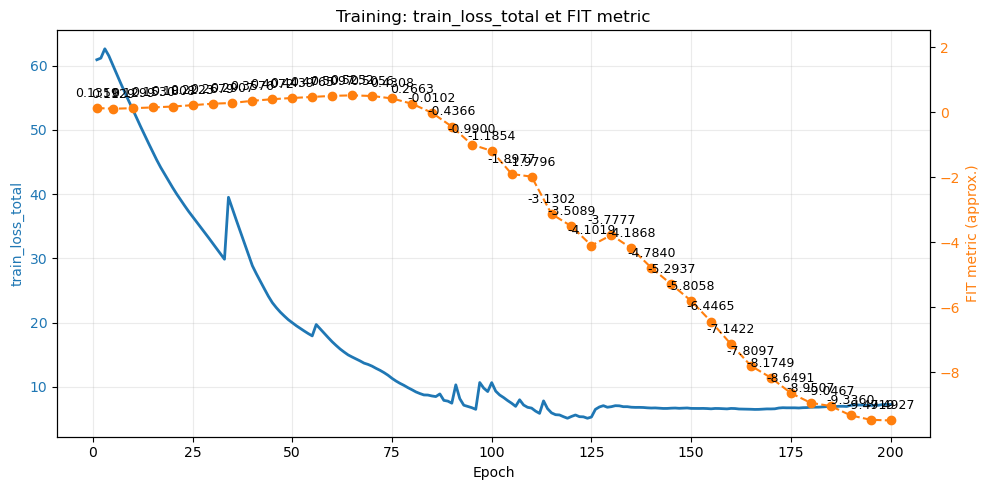

In [188]:
import matplotlib.pyplot as plt

history = getattr(tca.analyzer, 'training_history', None)
if not history or len(history.get('epoch', [])) == 0:
    raise ValueError("Aucun historique d'entrainement disponible. Execute d'abord la cellule d'entrainement.")

epochs = history['epoch']
train_loss_total = history['train_loss_total']
fit_epochs = history['fit_metric_points_epoch']
fit_values = history['fit_metric_points_value']

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(epochs, train_loss_total, color='tab:blue', linewidth=2, label='train_loss_total')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('train_loss_total', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(alpha=0.25)

ax2 = ax1.twinx()
if len(fit_epochs) > 0:
    ax2.plot(fit_epochs, fit_values, color='tab:orange', marker='o', linestyle='--', label='FIT metric')
    for x, y in zip(fit_epochs, fit_values):
        ax2.annotate(f"{y:.4f}", (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)

    # Add headroom so FIT labels are easier to read near the top edge.
    fit_min = min(fit_values)
    fit_max = max(fit_values)
    fit_span = max(fit_max - fit_min, 1e-6)
    ax2.set_ylim(bottom=fit_min - 0.05 * fit_span, top=fit_max + 0.20 * fit_span)

ax2.set_ylabel('FIT metric (approx.)', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
# ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
plt.title('Training: train_loss_total et FIT metric')
plt.tight_layout()
plt.show()

# # afficher la valeur du FIT au moment du best fit_metric
# if history.get('best_fit_metric') is not None:
#     print(f"Best FIT metric during training: {history['best_fit_metric']:.4f}")

In [85]:
import itertools
import time
import numpy as np
import pandas as pd

# Mini grid search orientee FIT metric.
# Ajuste ces grilles si tu veux explorer plus (ou moins) de configurations.
search_space = {
    'rank': [3, 4, 6],
    'time_window_length': [3, 5],
    'reg_term_ns': [0.3, 0.5],
    'reg_term_s': [0.3, 0.5],
    'learning_rate': [1e-2, 5e-3],
}

n_epochs_search = 200
fit_metric_every_n_epochs_search = 5
fit_metric_eval_max_patients_search = 128
num_workers_search = 0
early_stopping_patience_search = 8
early_stopping_min_delta_search = 1e-4
metric_search = 'Bernoulli'

# Pour limiter le temps de calcul, on peut echantillonner les combinaisons.
max_trials = 12  # mets None pour tout lancer
random_seed = 42

all_combos = list(itertools.product(
    search_space['rank'],
    search_space['time_window_length'],
    search_space['reg_term_ns'],
    search_space['reg_term_s'],
    search_space['learning_rate'],
))

rng = np.random.default_rng(random_seed)
if max_trials is not None and max_trials < len(all_combos):
    selected_idx = rng.choice(len(all_combos), size=max_trials, replace=False)
    combos = [all_combos[i] for i in selected_idx]
else:
    combos = all_combos

print(f'Total combinaisons: {len(all_combos)} | Executees: {len(combos)}')

results = []

for i, (rank_i, twl_i, reg_ns_i, reg_s_i, lr_i) in enumerate(combos, start=1):
    print('\n' + '=' * 90)
    print(
        f"[{i}/{len(combos)}] rank={rank_i}, twl={twl_i}, reg_ns={reg_ns_i}, "
        f"reg_s={reg_s_i}, lr={lr_i}"
    )

    # Nouvelle instance a chaque essai pour eviter les effets de bord.
    tca_trial = TCA(
        data=timed_event_structure,
        index_col='ID_PATIENT',
        time_col='Time',
        event_col='Event',
        mode='multidimensional',
    )
    tca_trial.analyzer.transform_time_event_structure_to_tensor()
    tensor_trial = tca_trial.analyzer.get_tensor()

    t0 = time.perf_counter()
    tca_trial.analyzer.fit_swotted_decomposition(
        tensor_trial,
        rank_i,
        twl_i,
        reg_ns_i,
        reg_s_i,
        metric_search,
        lr_i,
        n_epochs_search,
        fit_metric_every_n_epochs=fit_metric_every_n_epochs_search,
        fit_metric_eval_max_patients=fit_metric_eval_max_patients_search,
        num_workers=num_workers_search,
        early_stopping_patience=early_stopping_patience_search,
        early_stopping_min_delta=early_stopping_min_delta_search,
        early_stopping_monitor='fit_metric',
    )
    elapsed = time.perf_counter() - t0

    hist = getattr(tca_trial.analyzer, 'training_history', {}) or {}
    best_fit = hist.get('best_fit_metric', None)
    best_fit_epoch = hist.get('best_fit_metric_epoch', None)
    final_fit = hist.get('final_fit_metric', None)
    epochs_run = len(hist.get('epoch', []))

    results.append({
        'rank': rank_i,
        'time_window_length': twl_i,
        'reg_term_ns': reg_ns_i,
        'reg_term_s': reg_s_i,
        'learning_rate': lr_i,
        'epochs_run': epochs_run,
        'best_fit_metric': best_fit,
        'best_fit_epoch': best_fit_epoch,
        'final_fit_metric': final_fit,
        'elapsed_s': round(elapsed, 2),
    })

results_df = pd.DataFrame(results)
if not results_df.empty:
    results_df = results_df.sort_values(
        by=['best_fit_metric', 'final_fit_metric'],
        ascending=False,
        na_position='last'
    ).reset_index(drop=True)

print('\nTop configurations (FIT):')
display(results_df.head(10))

if not results_df.empty:
    best = results_df.iloc[0].to_dict()
    print('\nMeilleure configuration candidate:')
    print(best)

INFO:root:TCA object initialized successfully
INFO:root:The multidimensional analysis mode is set. TCA object will analyze the data accordingly.


Total combinaisons: 48 | Executees: 12

[1/12] rank=4, twl=3, reg_ns=0.3, reg_s=0.3, lr=0.005
Dataset :
data shape:  (20435, 3)
state coding:
    label  label encoded
0      0              0
1      1              1
2      2              2
3      3              3


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\nicolas.grevet\AppData\Local\anaconda3\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | model        | SlidingWindow | 0      | train
  | other params | n/a           | 48     | n/a  
-------------------------------------------------------
48        Trainable params
0         Non-trainable params
48        Total params
0.000     Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval mode
c:\Users\nicolas.grevet\AppData\Local\anaconda3\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the va

Training: |          | 0/? [00:00<?, ?it/s]

Epoch 1/200 : - train_loss_Ph: 61.407459 - train_loss_W: 73.393837 - train_loss_total: 134.801296 - duration: 1.44s - FIT metric: 0.3249
    early stopping: Metric fit_metric initialized at 0.325.
    checkpoint: New best FIT metric = 0.3249 at epoch 1.
Epoch 2/200 : - train_loss_Ph: 16.300949 - train_loss_W: 30.855762 - train_loss_total: 47.156712 - duration: 1.39s
Epoch 3/200 : - train_loss_Ph: 16.258148 - train_loss_W: 30.630386 - train_loss_total: 46.888535 - duration: 1.53s
Epoch 4/200 : - train_loss_Ph: 16.407818 - train_loss_W: 30.558081 - train_loss_total: 46.965899 - duration: 1.43s
Epoch 5/200 : - train_loss_Ph: 16.414455 - train_loss_W: 30.343010 - train_loss_total: 46.757465 - duration: 1.41s - FIT metric: 0.1432
Epoch 6/200 : - train_loss_Ph: 16.344879 - train_loss_W: 30.054317 - train_loss_total: 46.399197 - duration: 1.37s
Epoch 7/200 : - train_loss_Ph: 16.258537 - train_loss_W: 29.750355 - train_loss_total: 46.008892 - duration: 1.37s
Epoch 8/200 : - train_loss_Ph: 16.1

...

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\nicolas.grevet\AppData\Local\anaconda3\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | model        | SlidingWindow | 0      | train
  | other params | n/a           | 60     | n/a  
-------------------------------------------------------
60        Trainable params
0         Non-trainable params
60        Total params
0.000     Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval mode
c:\Users\nicolas.grevet\AppData\Local\anaconda3\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the va

Training: |          | 0/? [00:00<?, ?it/s]

Epoch 1/200 : - train_loss_Ph: 47.996395 - train_loss_W: 60.325195 - train_loss_total: 108.321590 - duration: 1.89s - FIT metric: 0.0499
    early stopping: Metric fit_metric initialized at 0.050.
    checkpoint: New best FIT metric = 0.0499 at epoch 1.
Epoch 2/200 : - train_loss_Ph: 14.087352 - train_loss_W: 28.249140 - train_loss_total: 42.336492 - duration: 1.54s
Epoch 3/200 : - train_loss_Ph: 15.298052 - train_loss_W: 29.258959 - train_loss_total: 44.557011 - duration: 1.60s
Epoch 4/200 : - train_loss_Ph: 14.635874 - train_loss_W: 28.357124 - train_loss_total: 42.992998 - duration: 1.62s
Epoch 5/200 : - train_loss_Ph: 14.050489 - train_loss_W: 27.590866 - train_loss_total: 41.641356 - duration: 1.63s - FIT metric: 0.1471
    early stopping: Metric fit_metric improved by 0.097 >= min_delta = 0.0001. New best score: 0.147
    checkpoint: New best FIT metric = 0.1471 at epoch 5.
Epoch 6/200 : - train_loss_Ph: 14.104665 - train_loss_W: 27.437468 - train_loss_total: 41.542132 - duration

,rank,time_window_length,reg_term_ns,reg_term_s,learning_rate,epochs_run,best_fit_metric,best_fit_epoch,final_fit_metric,elapsed_s
0,3,3,0.3,0.5,0.005,130,0.473324,90,0.512550,816.17
1,3,3,0.5,0.3,0.010,95,0.466277,55,0.505688,672.51
2,6,3,0.5,0.3,0.010,90,0.452611,50,0.479590,654.36
3,6,5,0.3,0.3,0.010,90,0.452001,50,0.476012,654.00
4,4,5,0.3,0.3,0.005,130,0.438888,90,0.464648,819.91
5,6,5,0.3,0.5,0.010,90,0.435104,50,0.459059,654.96
6,4,5,0.5,0.3,0.005,150,0.432016,110,0.455470,894.13
7,3,5,0.3,0.3,0.005,125,0.429294,85,0.451890,807.31
8,6,5,0.5,0.5,0.010,100,0.414615,60,0.443370,695.77
9,4,5,0.5,0.5,0.010,95,0.399116,55,0.423237,671.20



Meilleure configuration candidate:
{'rank': 3.0, 'time_window_length': 3.0, 'reg_term_ns': 0.3, 'reg_term_s': 0.5, 'learning_rate': 0.005, 'epochs_run': 130.0, 'best_fit_metric': 0.47332435846328735, 'best_fit_epoch': 90.0, 'final_fit_metric': 0.5125497579574585, 'elapsed_s': 816.17}


Decomposed into 1336 pathways with rank 3 and time window length 3
Success rate for the entire dataset: 0.4000


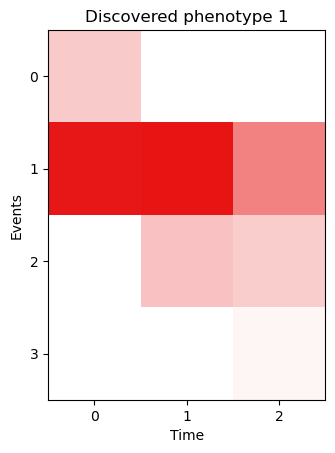

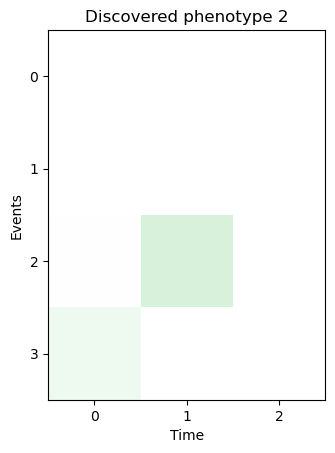

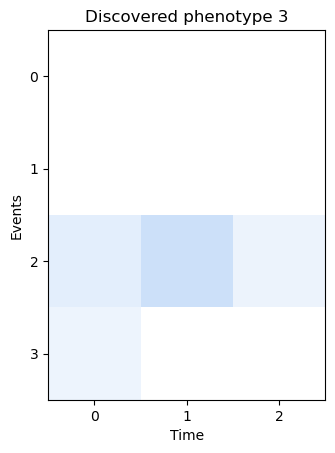

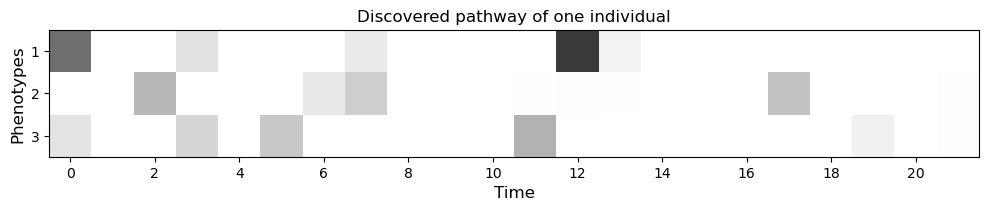

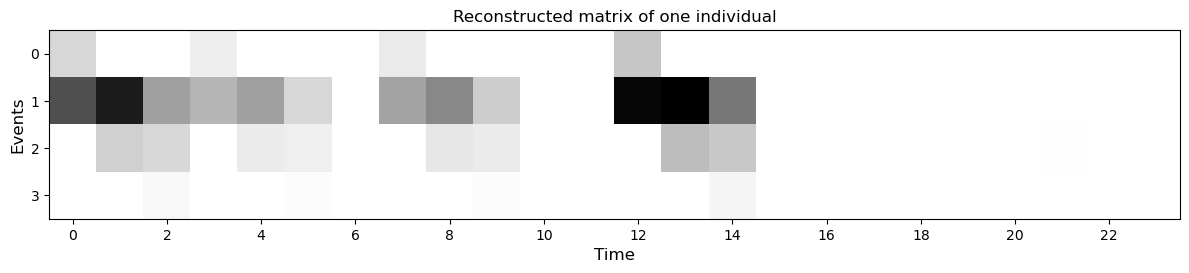

In [14]:
tca.analyzer.get_decomposition_results(labels=tca.label_to_encoded, id=patient_index)

In [ ]:
from sklearn.preprocessing import StandardScaler

ph_intensity = tca.analyzer.to_phenotype_intensity(scaler=StandardScaler())
print("Shape intensites:", ph_intensity.shape)
ph_intensity.head()

Shape intensites: (1336, 4)


,Phenotype_1,Phenotype_2,Phenotype_3,ID_PATIENT
0,1.041217,-0.240939,-0.640132,1
1,-0.525820,0.546464,0.686859,2
2,1.213404,0.614011,1.837701,3
3,1.818520,-0.559163,0.812819,4
4,0.150219,2.189097,-0.107967,5


### 5) Extraire les intensites et clusteriser

On resume chaque patient par ses intensites de phenotypes, puis on applique un clustering hierarchique.

INFO:root:Calculating distance matrix using metric: euclidean...
INFO:root:Time taken for computation: 0.00 seconds
INFO:root:Computing the linkage matrix using method: ward...
c:\Users\nicolas.grevet\dev\TrajectoryClusteringAnalysis.worktrees\copilot-worktree-2026-04-13T12-30-11\src\trajectoryclusteringanalysis\unidimensional\clustering.py:228: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = linkage(condensed_distance_matrix, method=method, optimal_ordering=optimal_ordering)
INFO:root:Linkage matrix computed successfully


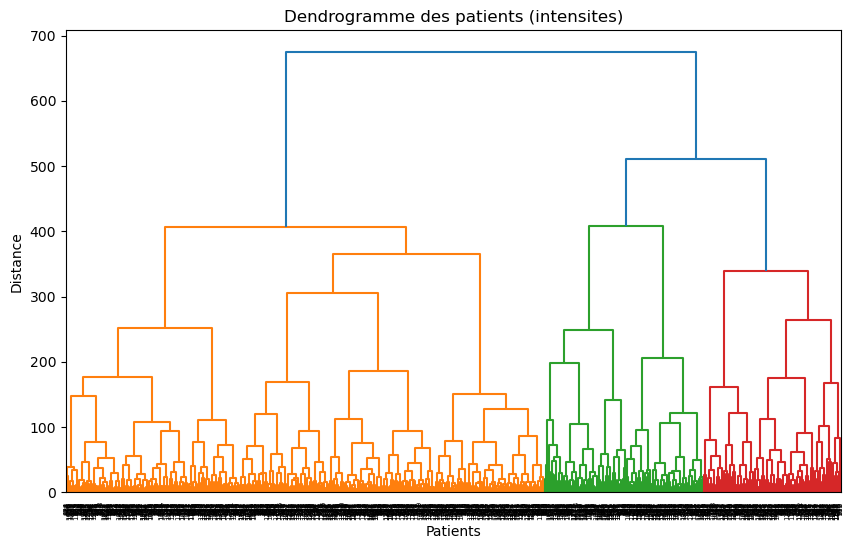

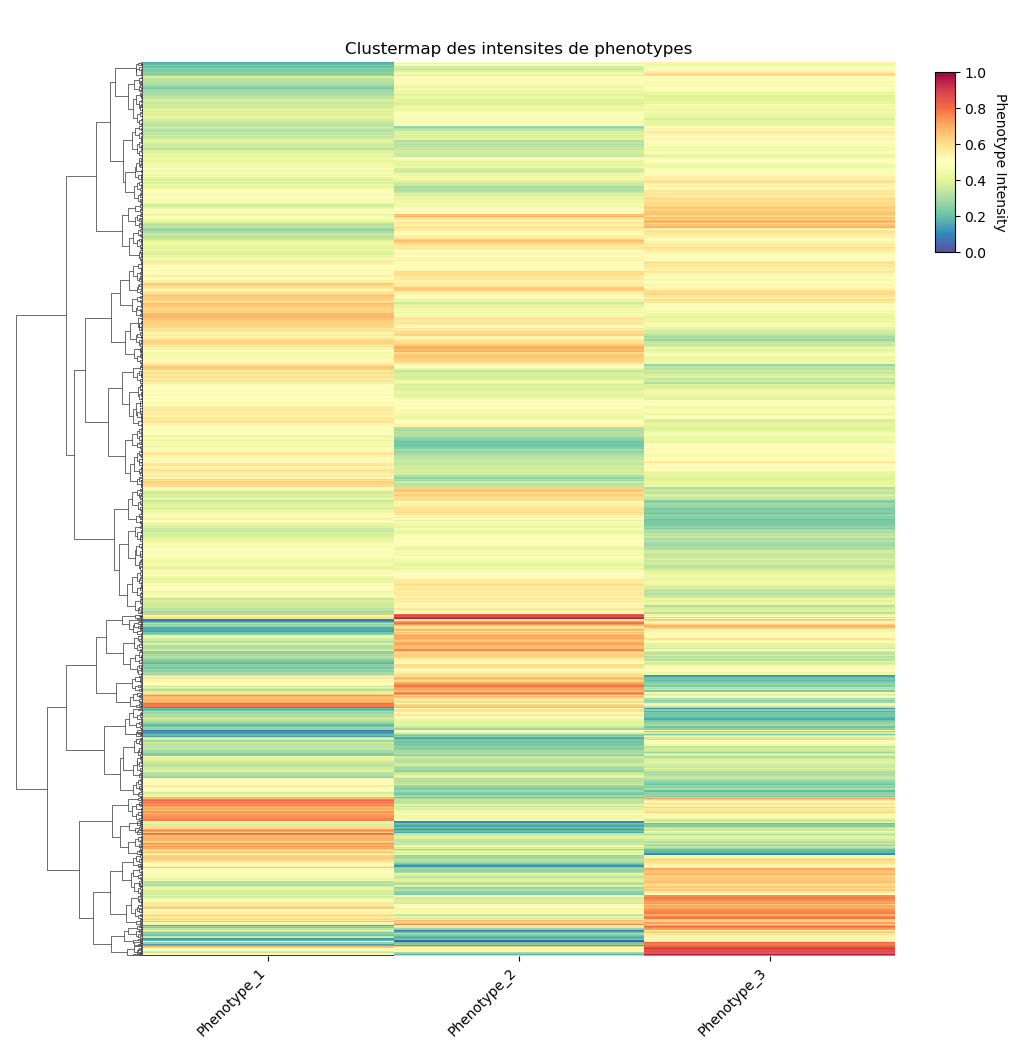

Effectifs par cluster:
1    825
2    141
3    133
4    237
Name: count, dtype: int64


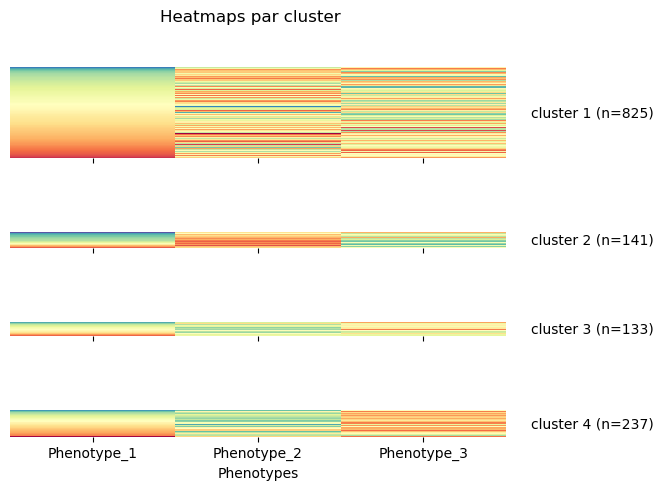

In [ ]:
distance_matrix = tca.compute_distance_matrix(data=ph_intensity, metric='euclidean')
linkage_matrix = tca.hierarchical_clustering(distance_matrix)

# Visualisations standard du package
tca.plot_dendrogram(linkage_matrix, title='Dendrogramme des patients (intensites)')
tca.plot_clustermap(ph_intensity, linkage_matrix, title='Clustermap des intensites de phenotypes')

clusters = tca.assign_clusters(linkage_matrix, num_clusters=4)
print("Effectifs par cluster:")
print(pd.Series(clusters).value_counts().sort_index())

tca.plot_cluster_heatmaps(ph_intensity, clusters, sorted=True, title='Heatmaps par cluster')